#### Setup & Imports

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import pydicom
import time
from pathlib import Path

import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

from src.utils import get_raw_dir
from src.dataset import PneumoniaDataset
from src.preprocessing import (
    cache_image, train_transform, val_transform,
    IMAGENET_MEAN, IMAGENET_STD
)

#### 1. Load Data & Raw Dataset (No Transform)

In [2]:
RAW_DIR = get_raw_dir()

In [3]:
train_df = pd.read_csv('../data/splits/train.csv')
val_df = pd.read_csv('../data/splits/val.csv')
patient_labels = pd.read_csv('../data/processed/labels.csv')

In [4]:
# Raw check: no transform yet, just confirm the Dataset class reads DICOMs correctly
raw_dataset = PneumoniaDataset(train_df, RAW_DIR / "stage_2_train_images")
img, label = raw_dataset[0]
print("Shape:", img.shape)
print("Image Datatype:", img.dtype)
print("Label:", label)

Shape: (1024, 1024, 3)
Image Datatype: uint8
Label: 2


#### 2. Preprocessing Decisions
Resolution → 224×224 (DenseNet121 input size). uint8 → float32 [0,1] (handled by `T.ToTensor()`). Grayscale replicated to 3 channels to match the ImageNet-pretrained backbone's expected input shape.

In [5]:
# Confirm pixel range varies naturally across images (expected, not a bug)
for i in range(5):
    img, label = raw_dataset[i]
    print(f"Sample {i}: min={img.min()}, max={img.max()}")

Sample 0: min=0, max=206
Sample 1: min=0, max=255
Sample 2: min=0, max=254
Sample 3: min=0, max=226
Sample 4: min=0, max=255


In [6]:
img_float = img.astype(np.float32) / 255.0
print("After float conversion:")
print("Datatype:", img_float.dtype)
print("Min:", img_float.min())
print("Max:", img_float.max())

After float conversion:
Datatype: float32
Min: 0.0
Max: 1.0


In [7]:
# raw_dataset already returns a 3-channel image (replication happens
# inside PneumoniaDataset.__getitem__), so no need to stack again here
print("Shape from dataset (already 3-channel):", img.shape)

Shape from dataset (already 3-channel): (1024, 1024, 3)


#### 3. RescaleSlope / RescaleIntercept Check
Checked absent on this dataset — pixel values are usable directly, no linear rescale needed before normalization.

In [8]:
ds = pydicom.dcmread(RAW_DIR / "stage_2_train_images" / f"{train_df.iloc[0]['patientId']}.dcm")
print("RescaleSlope:", hasattr(ds, 'RescaleSlope'))
print("RescaleIntercept:", hasattr(ds, 'RescaleIntercept'))

RescaleSlope: False
RescaleIntercept: False


#### 4. Transforms — Resize & ImageNet Normalization
No augmentation here — `val_transform` is used for validation/test so evaluation stays deterministic.

In [9]:
img, label = raw_dataset[0]  # already (1024,1024,3) uint8, no re-stacking needed
transformed = val_transform(img)
print("Transformed shape:", transformed.shape)
print("Transformed data type:", transformed.dtype)
print("Transformed min item:", transformed.min().item())
print("Transformed max item:", transformed.max().item())

Transformed shape: torch.Size([3, 224, 224])
Transformed data type: torch.float32
Transformed min item: -2.1007792949676514
Transformed max item: 1.6813944578170776


#### 5. Augmentation (Train Split Only)
Horizontal flip, small rotation, and brightness/contrast jitter — anatomically safe for chest X-rays. Deliberately excludes vertical flip and heavy rotation/crop, which would distort or cut off the pathology.

In [10]:
augmented = train_transform(img)
print("Augmented shape:", augmented.shape)
print("Augmented data type:", augmented.dtype)

Augmented shape: torch.Size([3, 224, 224])
Augmented data type: torch.float32


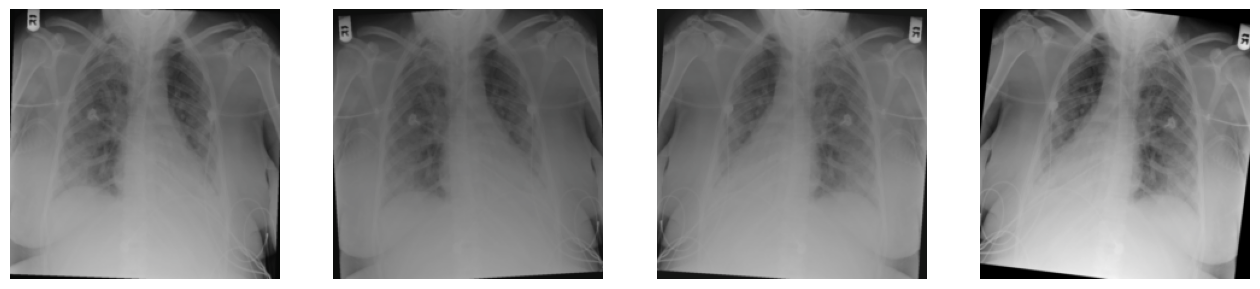

In [11]:
# Run the same image through train_transform 4 times to see augmentation vary
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    aug = train_transform(img)
    aug_np = aug.permute(1, 2, 0).numpy()
    aug_np = aug_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    aug_np = np.clip(aug_np, 0, 1)
    axes[i].imshow(aug_np)
    axes[i].axis('off')
plt.show()

#### 6. Cache Preprocessed Images to Disk
Decodes each DICOM once, resizes, and saves as `.npy` — avoids repeated pydicom decode cost on every epoch.

In [12]:
cache_dir = Path('../data/cache')
cache_dir.mkdir(parents=True, exist_ok=True)

all_patient_ids = patient_labels['patientId'].tolist()
for pid in tqdm(all_patient_ids):
    cache_image(pid, RAW_DIR / "stage_2_train_images", cache_dir)

  0%|          | 0/26684 [00:00<?, ?it/s]

100%|██████████| 26684/26684 [00:04<00:00, 6069.36it/s]


#### 7. Final Dataset & DataLoader (Cache-Enabled)
`cache_dir` is passed in this time, so `PneumoniaDataset` actually reads from the `.npy` cache instead of re-decoding DICOMs.

In [13]:
train_dataset = PneumoniaDataset(train_df, RAW_DIR / "stage_2_train_images",
                                  transform=train_transform, cache_dir=cache_dir)
val_dataset = PneumoniaDataset(val_df, RAW_DIR / "stage_2_train_images",
                                transform=val_transform, cache_dir=cache_dir)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [15]:
images, labels = next(iter(train_loader))
print(images.shape, images.dtype, labels.shape)

torch.Size([16, 3, 224, 224]) torch.float32 torch.Size([16])


In [16]:
# Confirms the cache is actually being read (should be noticeably faster than
# the pre-cache DICOM-decode path)
start = time.time()
images, labels = next(iter(train_loader))
print(f"Batch load time: {time.time()-start:.2f}s")

Batch load time: 0.21s


#### 8. Sanity Check — Visualize a Batch

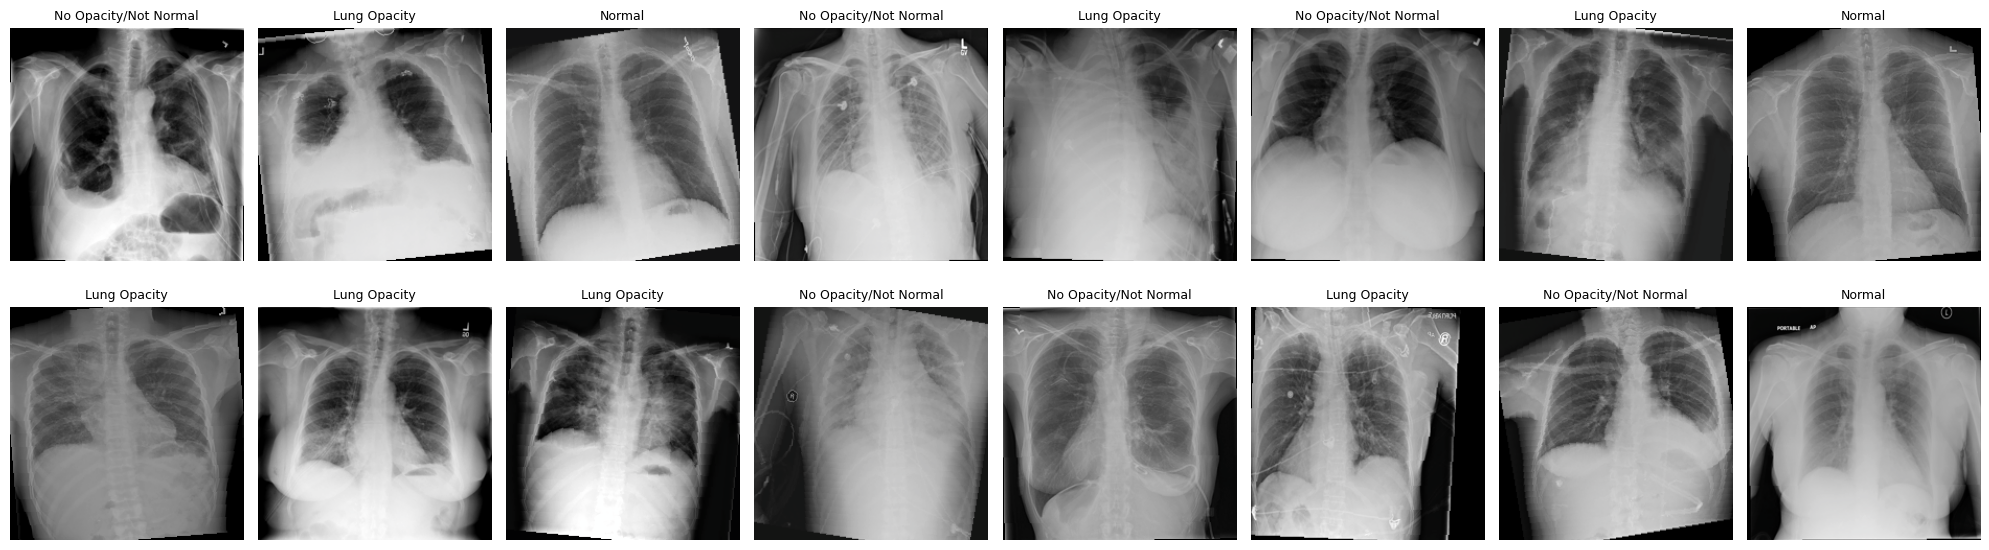

In [17]:
class_names = {0: 'Normal', 1: 'No Opacity/Not Normal', 2: 'Lung Opacity'}

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    img_np = images[i].permute(1, 2, 0).numpy()
    img_np = img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    ax.set_title(class_names[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

#### 9. Cross-Check Bounding Boxes
Validates the original label source, not the `Dataset` class (which discards boxes for classification) — confirms `Lung Opacity` really corresponds to a visible abnormality in a sensible location.

In [18]:
labels_df = pd.read_csv(RAW_DIR / "stage_2_train_labels.csv")

In [19]:
multi_box_ids = labels_df[labels_df['Target']==1]['patientId'].value_counts()
multi_box_ids = multi_box_ids[multi_box_ids > 1].index.tolist()
sample_pid = multi_box_ids[0]

In [20]:
boxes = labels_df[labels_df['patientId'] == sample_pid]
print(boxes)

                                 patientId      x      y  width  height  \
1133  0d5bc737-03de-4bb8-98a1-45b7180c3e0f  342.0  157.0  148.0   113.0   
1134  0d5bc737-03de-4bb8-98a1-45b7180c3e0f  633.0  128.0   90.0   195.0   
1135  0d5bc737-03de-4bb8-98a1-45b7180c3e0f  655.0  478.0  163.0   141.0   
1136  0d5bc737-03de-4bb8-98a1-45b7180c3e0f  214.0  374.0  193.0   251.0   

      Target  
1133       1  
1134       1  
1135       1  
1136       1  


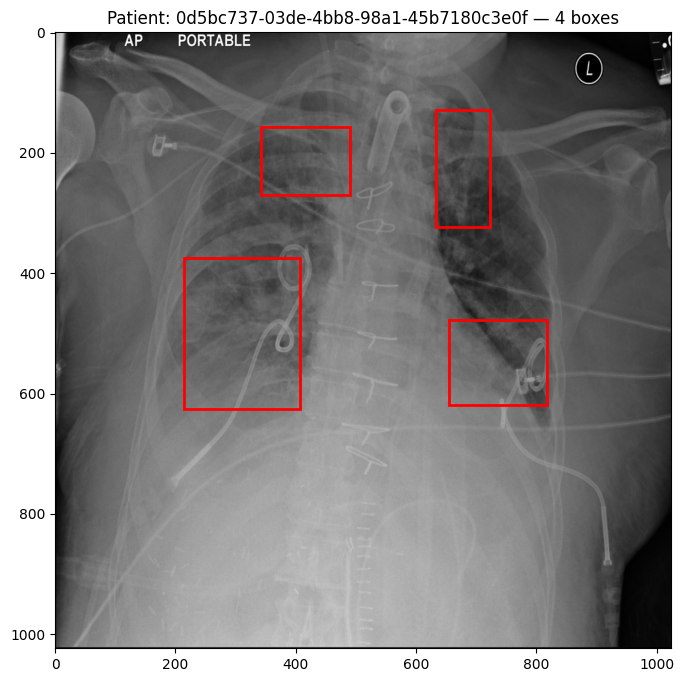

In [21]:
ds = pydicom.dcmread(RAW_DIR / "stage_2_train_images" / f"{sample_pid}.dcm")
img = ds.pixel_array

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img, cmap='gray')

for _, row in boxes.iterrows():
    rect = patches.Rectangle(
        (row['x'], row['y']), row['width'], row['height'],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

ax.set_title(f"Patient: {sample_pid} — {len(boxes)} boxes")
plt.show()

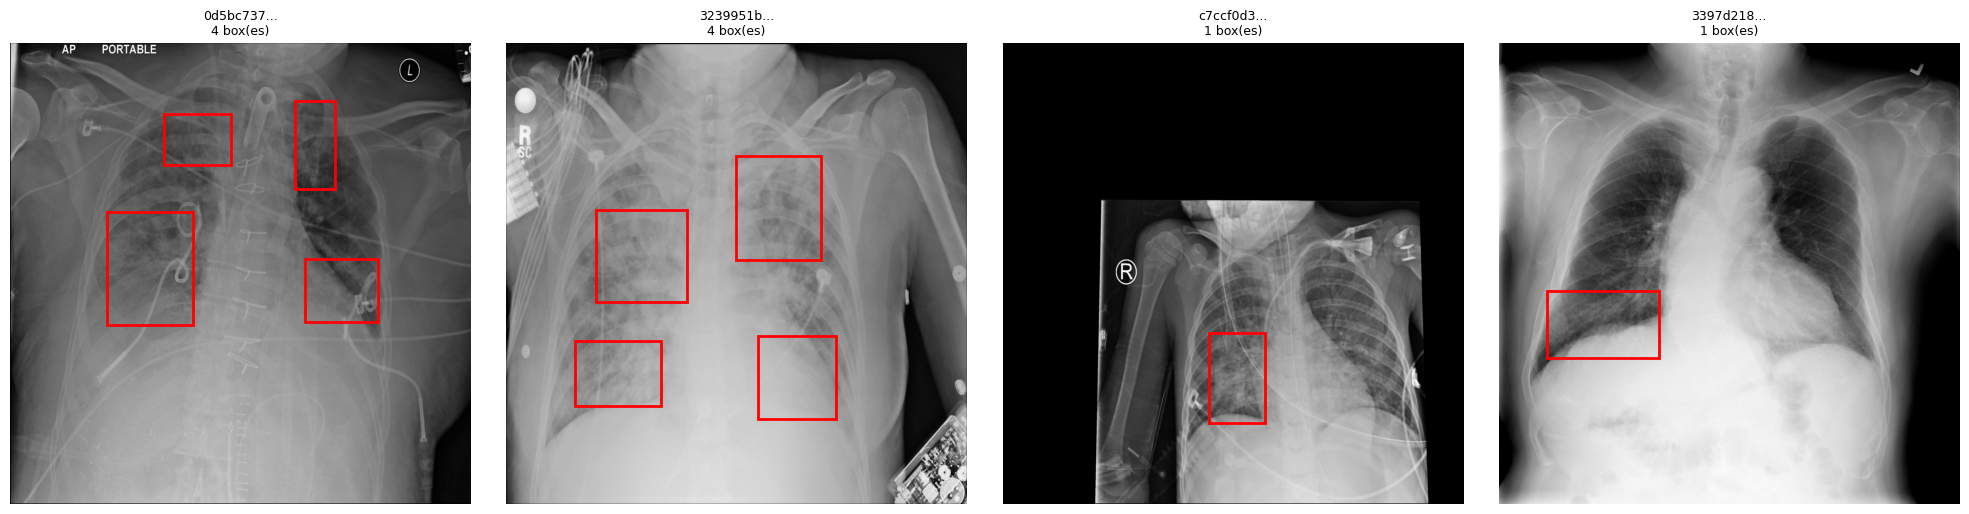

In [22]:
single_box_ids = labels_df[labels_df['Target']==1]['patientId'].value_counts()
single_box_ids = single_box_ids[single_box_ids == 1].index.tolist()

sample_pids = [multi_box_ids[0], multi_box_ids[1], single_box_ids[0], single_box_ids[1]]

fig, axes = plt.subplots(1, len(sample_pids), figsize=(20, 5))

for i, pid in enumerate(sample_pids):
    ds = pydicom.dcmread(RAW_DIR / "stage_2_train_images" / f"{pid}.dcm")
    img = ds.pixel_array
    boxes = labels_df[labels_df['patientId'] == pid]

    axes[i].imshow(img, cmap='gray')
    for _, row in boxes.iterrows():
        rect = patches.Rectangle(
            (row['x'], row['y']), row['width'], row['height'],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[i].add_patch(rect)

    axes[i].set_title(f"{pid[:8]}...\n{len(boxes)} box(es)", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()